---
title: 'Practical 1: describing and representing data'
subtitle: "Getting to know the schools data"
---

## Introduction

In the lecture you watched me explore the Department for Education's school
performance data: what type each variable was, what shape it had, where the
gaps were, and which schools sat a long way from everyone else.

This practical asks you to do the same thing yourself, on the same data, but
**slicing it a different way**. By the end you should be able to open an
unfamiliar dataset and work out — quickly, and mostly visually — what is in
it and what might trip you up.

## Learning outcomes

By the end of this practical you should be able to:

1. Read a multi-file dataset into R or Python and join it together
2. Identify the **type** of each variable and say what you can legitimately do with it
3. Spot missing values and work out whether they are missing at random
4. Produce summary statistics, and compare a continuous variable across the groups of a categorical one using boxplots and violin plots
5. Say what your data can and cannot support a claim about

Every code block below is given in **both R and Python** — click the tabs to
switch. Pick whichever you are more comfortable with. You do not need to do
both, though comparing them is instructive.

## Before you start

The data is already in the course repository, under
`sessions/data/Performancetables_130242/2022-2023/`. You do not need to
download anything.

We use three files:

| File | What it holds |
|------|---------------|
| `england_ks4final.csv` | Key Stage 4 outcomes: Attainment 8, Progress 8, pupil numbers |
| `england_abs.csv` | Absence rates |
| `england_school_information.csv` | School characteristics: type, Ofsted, admissions policy, religious character |

# Task 1 — Read the data in

Two things in this code are worth understanding rather than copying blindly.

**The `na` values.** The DfE does not leave blanks. It writes `SUPP` when a
figure has been suppressed because the cohort is too small to publish safely,
`NE` for no entries, `LOWCOV` for low coverage, and so on. If you do not tell
your software these mean "missing", it will read the whole column as text.

**Dropping rows with no URN.** It's worth checking why some rows have no
school reference number before you filter them out — it turns out they're
local authority and national summary rows, not individual schools. We limit
the selection to schools only, which also avoids the silent duplication
you'd get from joining on a missing key, because a missing key matches
another missing key.



In [2]:
import pandas as pd
import numpy as np
from pathlib import Path

data_path = 'data/Performancetables_130242/2022-2023/'

na_all = ["", "NA", "SUPP", "NP", "NE", "SP", "SN", "LOWCOV", "NEW", "SUPPMAT"]

ks4 = pd.read_csv(data_path + "england_ks4final.csv",
                  na_values=na_all, dtype={"URN": str}, low_memory=False)
ks4 = ks4[ks4["URN"].notna()]
ks4 = ks4[["URN", "ATT8SCR", "P8MEA", "TOTPUPS", "TPUP", "PTFSM6CLA1A", "PTPRIORLO"]]
for c in ks4.columns.drop("URN"):
    ks4[c] = pd.to_numeric(ks4[c].astype(str).str.replace("%", "", regex=False),
                           errors="coerce")

absence = pd.read_csv(data_path + "england_abs.csv",
                      na_values=na_all, dtype={"URN": str}, low_memory=False)
absence = absence[absence["URN"].notna()].drop_duplicates("URN")
absence = absence[["URN", "PERCTOT"]]
absence["PERCTOT"] = pd.to_numeric(absence["PERCTOT"], errors="coerce")

school_info = pd.read_csv(data_path + "england_school_information.csv",
                          na_values=na_all, dtype={"URN": str}, low_memory=False)
school_info = school_info[["URN", "SCHNAME", "LANAME", "MINORGROUP",
                           "OFSTEDRATING", "ADMPOL", "RELCHAR", "GENDER"]]

schools = ks4.merge(school_info, on="URN", how="left") \
             .merge(absence, on="URN", how="left")

len(schools)

5657

# Task 2 — First look: what have you got?

Before computing anything, find out how big the data is, what the columns are
called, and what types your software thinks they are.



In [3]:
print(schools.shape)
schools.info()

(5657, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5657 entries, 0 to 5656
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   URN           5657 non-null   object 
 1   ATT8SCR       4631 non-null   float64
 2   P8MEA         3616 non-null   float64
 3   TOTPUPS       5586 non-null   float64
 4   TPUP          5533 non-null   float64
 5   PTFSM6CLA1A   3979 non-null   float64
 6   PTPRIORLO     3979 non-null   float64
 7   SCHNAME       5657 non-null   object 
 8   LANAME        5657 non-null   object 
 9   MINORGROUP    5657 non-null   object 
 10  OFSTEDRATING  4816 non-null   object 
 11  ADMPOL        5211 non-null   object 
 12  RELCHAR       3215 non-null   object 
 13  GENDER        5657 non-null   object 
 14  PERCTOT       4154 non-null   float64
dtypes: float64(7), object(8)
memory usage: 663.1+ KB


#### Question

How many rows are there, and how many of them actually have an Attainment 8
score? Why might those two numbers differ?

In [4]:
## Number of unique schools
#len("??")

## Number of schools with attainment 8 scores
#len("??")

#### Answer

Roughly a fifth of the rows have no Attainment 8 score at all. Some are
schools that entered no pupils for KS4; some are schools whose results were
suppressed. **We return to this in Task 4 — do not just delete them yet.**

# Task 3 — What kind of variables are these?

In the lecture we sorted variables two ways: Stevens' four **levels of
measurement**, and the finer list of **statistical data types**.

Work through this table for the columns in your data. The first row is done
for you.

| Variable | What it is | Level of measurement | Statistical type |
|----------|-----------|---------------------|------------------|
| `ATT8SCR` | Average Attainment 8 score | ratio | real-valued |
| `TOTPUPS` | Pupils on roll | ? | ? |
| `OFSTEDRATING` | Ofsted judgement | ? | ? |
| `LANAME` | Local authority | ? | ? |
| `P8MEA` | Progress 8 | ? | ? |
| `PERCTOT` | % of sessions missed | ? | ? |

#### Question

Have a go before revealing. The trap is `P8MEA` — think about what its zero means.

#### Answer

| Variable | Level of measurement | Statistical type |
|----------|---------------------|------------------|
| `TOTPUPS` | ratio | count |
| `OFSTEDRATING` | ordinal | ordinal |
| `LANAME` | nominal | categorical |
| `P8MEA` | **interval** | real-valued additive |
| `PERCTOT` | ratio | real-valued multiplicative |

`P8MEA` has a meaningful zero — average expected progress — but it is not a
*true* zero, so ratios are meaningless. A school on 1.0 has not made twice
the progress of a school on 0.5.

## Getting the type wrong, in code

Let's check the data type of each of the columns, the same way you would for
any new dataset. The numeric ones came in fine here, because we coerced them
with `parse_number()` / `pd.to_numeric()` while reading the data in — but
`OFSTEDRATING` is more subtle. Knowing it is ordinal is not enough. **Your
code has to know it too**, and by default it does not.

Read that column in and ask for its categories in order:



In [5]:
# As it arrives: just text
sorted(schools["OFSTEDRATING"].dropna().unique())

['Good',
 'Inadequate',
 'Outstanding',
 'Requires improvement',
 'Serious Weaknesses',
 'Special Measures']



**Good, Inadequate, Outstanding, Requires improvement.**

That is not a ranking — it is the **alphabet**. Every table you group by it,
every plot you facet by it, and every axis you draw will come out in that
order, and none of them will warn you.

The fix is to store it as an **ordered** type, stating the order yourself. But
there is a trap inside the fix, so we check as we go:



In [6]:
rating_order = ["Special Measures", "Serious Weaknesses", "Inadequate",
                "Requires improvement", "Good", "Outstanding"]

before = schools["OFSTEDRATING"].isna().sum()

schools["OFSTEDRATING"] = pd.Categorical(schools["OFSTEDRATING"],
                                         categories=rating_order,
                                         ordered=True)

print({"missing_before": int(before),
       "missing_after": int(schools["OFSTEDRATING"].isna().sum())})

{'missing_before': 841, 'missing_after': 841}




Both `factor()` and `pd.Categorical()` turn **any value you did not list**
into a missing value, without a word of warning.

Leave one real category out of `rating_order` — `Inadequate` is easy to
forget, because most schools in that state are labelled with the more
specific *Serious Weaknesses* or *Special Measures* — and those schools
silently vanish from every table and plot that follows.

If the two numbers above are not identical, you have just deleted data.

Now every table, plot and model respects the real order.

#### Question

Plot mean Attainment 8 by Ofsted rating **before** and **after** setting the
order. What changes, and what does *not*?

#### Answer

The numbers do not change at all — the same schools are in the same groups,
and each group's mean is identical either way.

What changes is the **order the categories come out in**, and therefore what
the chart appears to say. Alphabetically ordered, the bars rise and fall with
no pattern and the chart looks like noise. Correctly ordered, you see a clean
monotonic climb from Special Measures to Outstanding.

This is the part worth remembering: **nothing errored, and no number was
wrong.** The only thing that was wrong was the story the chart told.

The same trap has teeth in modelling. Ordinal data frequently arrives
**already coded as numbers** — Ofsted as 1 to 5, a Likert scale as 1 to 7.
Software cannot tell the difference between that and a genuine measurement,
so it will happily let you put it into a regression as a continuous predictor
and report "each additional unit is worth *x* points".

That claim assumes every step on the scale is the same size. As the lecture
showed, the Ofsted steps are nowhere near equal.

# Task 4 — Missing values

Let's check how much data is missing for each column in the dataframe — this
will help us understand the completeness of the data. Earlier you already
found that not every row has an Attainment 8 score; now find out whether
those gaps are random.

In [7]:
cols = ["ATT8SCR", "P8MEA", "PERCTOT", "PTFSM6CLA1A", "OFSTEDRATING"]
print((schools[cols].isna().mean() * 100).round(1))

tmp = schools[schools["TOTPUPS"].notna()].copy()
tmp["p8"] = np.where(tmp["P8MEA"].isna(),
                     "Progress 8 missing", "Progress 8 present")
print(tmp.groupby("p8")["TOTPUPS"].agg(schools="size", median_pupils="median"))

ATT8SCR         18.1
P8MEA           36.1
PERCTOT         26.6
PTFSM6CLA1A     29.7
OFSTEDRATING    14.9
dtype: float64
                    schools  median_pupils
p8                                        
Progress 8 missing     1981          126.0
Progress 8 present     3605         1019.0




1. Are schools with a missing Progress 8 score bigger or smaller than average?
2. Look up what `SUPP` means in the DfE guidance. Does that explain the pattern?
3. If you dropped every row with a missing value, which schools would you have quietly removed from your analysis?

# Task 5 — Describe one continuous variable

Pick a continuous variable. `ATT8SCR` is the obvious one, but `PERCTOT`
(absence) or `PTFSM6CLA1A` (% disadvantaged) are just as good, and it is more
interesting if the room does not all pick the same one.



In [8]:
schools["ATT8SCR"].describe()

count    4631.000000
mean       39.768063
std        17.529873
min         0.000000
25%        34.500000
50%        43.600000
75%        50.200000
max        87.600000
Name: ATT8SCR, dtype: float64



Is the mean above or below the median? What does that suggest about the
shape of the data — even before you have plotted anything? (You will get to
plot it properly next week.)

# Task 6 — Compare groups with boxplots and violins

This is the heart of the practical.

In the lecture I split Attainment 8 by **school type**, and the low hump
turned out to be special schools. Your job is to split it by something
**different** and see what you find.

From here on we work only with mainstream state-funded secondaries, so that
we are comparing like with like.



In [9]:
mainstream = schools[
    schools["MINORGROUP"].isin(["Academy", "Maintained school"])
    & schools["ATT8SCR"].notna()
].copy()

len(mainstream)

3250



## A worked example: admissions policy

`ADMPOL` records whether a school selects by ability. Here is the comparison
done properly — a table *and* a plot, because neither is enough on its own.



                   n  mean  median   sd
ADMPOL                                 
Non-selective   2815  45.9    45.5  7.2
Selective        163  71.7    72.5  7.3
Not applicable    50  43.4    41.4  8.7


/var/folders/4n/x6w1yfcx01qbymrsfpz4ybq00000gn/T/ipykernel_18182/2029103052.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=sub, x="ATT8SCR", y="ADMPOL", scale="count",
/var/folders/4n/x6w1yfcx01qbymrsfpz4ybq00000gn/T/ipykernel_18182/2029103052.py:12: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='count'` for the same effect.
  sns.violinplot(data=sub, x="ATT8SCR", y="ADMPOL", scale="count",


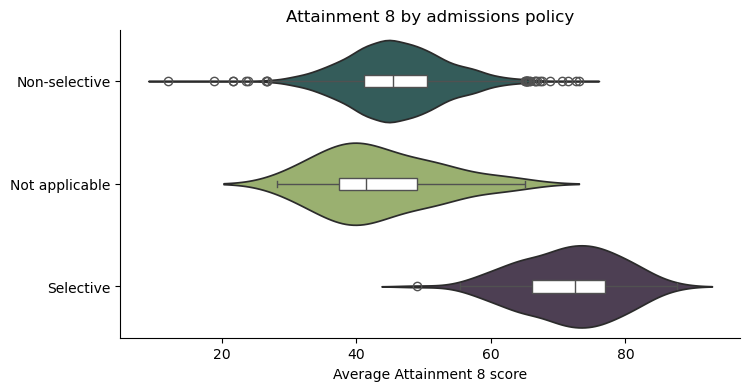

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

sub = mainstream[mainstream["ADMPOL"].notna()]

print(sub.groupby("ADMPOL")["ATT8SCR"]
         .agg(n="size", mean="mean", median="median", sd="std")
         .round(1)
         .sort_values("n", ascending=False))

fig, ax = plt.subplots(figsize=(8, 4))
sns.violinplot(data=sub, x="ATT8SCR", y="ADMPOL", scale="count",
               inner=None, palette=["#2E6260", "#9DBB65", "#4E3C56"], ax=ax)
sns.boxplot(data=sub, x="ATT8SCR", y="ADMPOL", width=0.12,
            showfliers=True, boxprops={"facecolor": "white"}, ax=ax)
ax.set_title("Attainment 8 by admissions policy")
ax.set_xlabel("Average Attainment 8 score")
ax.set_ylabel("")
sns.despine()
plt.show()



The violin is scaled by **count**, so its width tells you how many schools
are in each group. A boxplot alone would draw the 163 selective schools and
the 2,815 non-selective ones at exactly the same size, which would badly
mislead you about how much evidence sits behind each summary.

1. How big is the gap in mean Attainment 8 between selective and non-selective schools?
2. Is the **spread** different too, or only the middle?
3. Does this tell you selective schools *teach* better? What else could explain it?

## Your turn

#### Question

Repeat the table and the plot above using a **different** grouping variable.
Choose one of:

- `OFSTEDRATING` — the Ofsted judgement
- `GENDER` — mixed, boys, or girls
- `RELCHAR` — religious character
- `LANAME` — local authority (pick a handful, there are 150)

In [11]:
(mainstream
    .dropna(subset=["??"])
    .groupby("??")["ATT8SCR"]
    .agg(n="size", mean="mean", sd="std")
    .round(1)
    .reset_index()
    .sort_values("n", ascending=False))

KeyError: ['??']

#### Answer

Note that the ordering here comes out alphabetically, not by how good the
rating is. Ofsted rating is **ordinal**, and your software does not know
that. Converting it to an ordered factor fixes every table and plot at once.

Try `GENDER`. Single-sex schools look dramatically better than mixed ones.
Now cross-tabulate `GENDER` against `ADMPOL` before you believe it.

# Task 7 — Write it down

The point of all of the above is to be able to say something defensible. In
a few sentences each:

1. **What is in this dataset?** How many schools, over what period, measuring what?
2. **What did you filter out, and what did that change?** You dropped special and independent schools. Which questions can you no longer answer?
3. **Is the mean a good summary of your chosen variable?** What does the gap between mean and median suggest?
4. **Which grouping variable did you use, and what did the comparison show?**
5. **What is missing, and is it missing at random?**
6. **What would you want to check before claiming that the difference you found is real?**

Question 6 is the one the rest of this course exists to answer. Keep your
notes — we come back to this data in weeks 5 to 10, and next week you will
plot its distribution properly.

## You're done

Do not worry if some of the syntax is unfamiliar. What matters practising the exploratory data approach - always look at the data before you model it, and find out what is missing before you decide it does not matter.